In [71]:
import yaml
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
CONFIG_DIR = Path("../configs")
NAIVE_CONFIG_PATH = CONFIG_DIR / "train-less-year" / "naive" / "MSFT"
ARIMA_CONFIG_PATH = CONFIG_DIR / "train-less-year" / "arima" / "MSFT"
TIMES_CONFIG_PATH = CONFIG_DIR / "train-less-year" / "fm" / "MSFT"

In [73]:
naive_conf = []
arima_conf = []
times_conf = []
for file_path in os.listdir(NAIVE_CONFIG_PATH):
    with open(NAIVE_CONFIG_PATH / file_path, 'r' ) as file:
        conf = yaml.safe_load(file)
    naive_conf.append(conf)

for file_path in os.listdir(ARIMA_CONFIG_PATH):
    with open(ARIMA_CONFIG_PATH / file_path, 'r' ) as file:
        conf = yaml.safe_load(file)
    arima_conf.append(conf)

for file_path in os.listdir(TIMES_CONFIG_PATH):
    with open(TIMES_CONFIG_PATH / file_path, 'r' ) as file:
        conf = yaml.safe_load(file)
    times_conf.append(conf)

In [75]:
mape_col = 'MAPE'
days_col = 'training_period_value'
horizon_col = 'forecast_horizon'
model_type_col = 'Method'

# Define consistent plotting styles
palette = {'Naive': 'grey', 'ARIMA': 'orange', 'TimesFM': 'blue'}
training_period_value = list(
    set([l['training_period_value'] for l in times_conf])
)
horizon_length = list(
    set([l["horizon_length"] for l in times_conf])
)

training_period_value.sort()
horizon_length.sort()

In [76]:
naive_results = []
arima_results = []
times_results = []

for conf in naive_conf:
    naive_results.append({
        'Method': 'Naive',
        'training_period_value': conf['training_period_value'],
        'forecast_horizon': conf['horizon_length'],
        'MAPE': conf['evaluation_metrics']['mape']
    })

for conf in arima_conf:
    arima_results.append({
        'Method': 'ARIMA',
        'training_period_value': conf['training_period_value'],
        'forecast_horizon': conf['horizon_length'],
        'MAPE': conf['evaluation_metrics']['mape']
    })

for conf in times_conf:
    times_results.append({
        'Method': 'TimesFM',
        'training_period_value': conf['training_period_value'],
        'forecast_horizon': conf['horizon_length'],
        'MAPE': conf['evaluation_metrics']['mape']
    })

all_results = []
all_results.extend(naive_results)
all_results.extend(arima_results)
all_results.extend(times_results)

df_mape_results = pd.DataFrame(all_results)

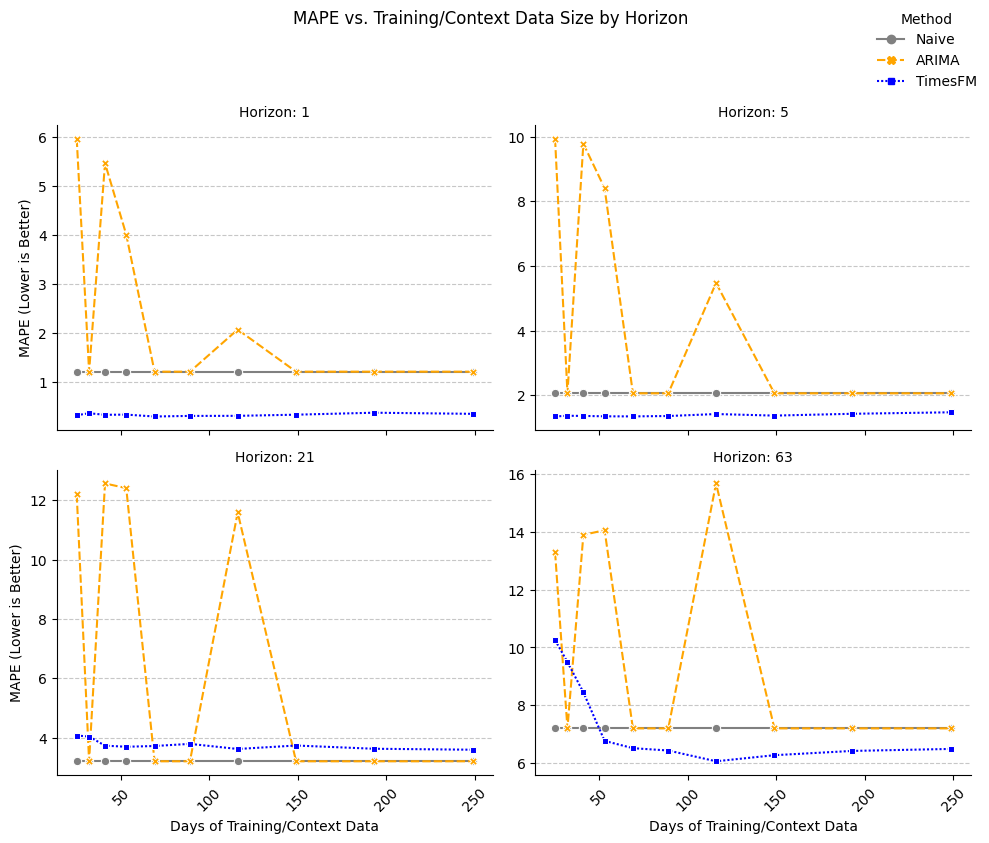

In [83]:
g2 = sns.relplot(
    data=df_mape_results,
    x=days_col,
    y=mape_col,
    hue=model_type_col,
    col=horizon_col,
    kind='line',
    style=model_type_col,
    markers=True,
    palette=palette,
    height=4,
    aspect=1.1,
    col_order=horizon_length,
    col_wrap=2,
    facet_kws={'sharey': False} # Keep y-axis consistent
)
sns.move_legend(g2, 'upper right')
# plt.xscale('log')
g2.figure.suptitle(f'MAPE vs. Training/Context Data Size by Horizon', y=1.03)
g2.set_axis_labels('Days of Training/Context Data', f'{mape_col} (Lower is Better)')
g2.set_titles("Horizon: {col_name}")
plt.tight_layout(rect=[0, 0, 1, 0.97])
for ax in g2.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


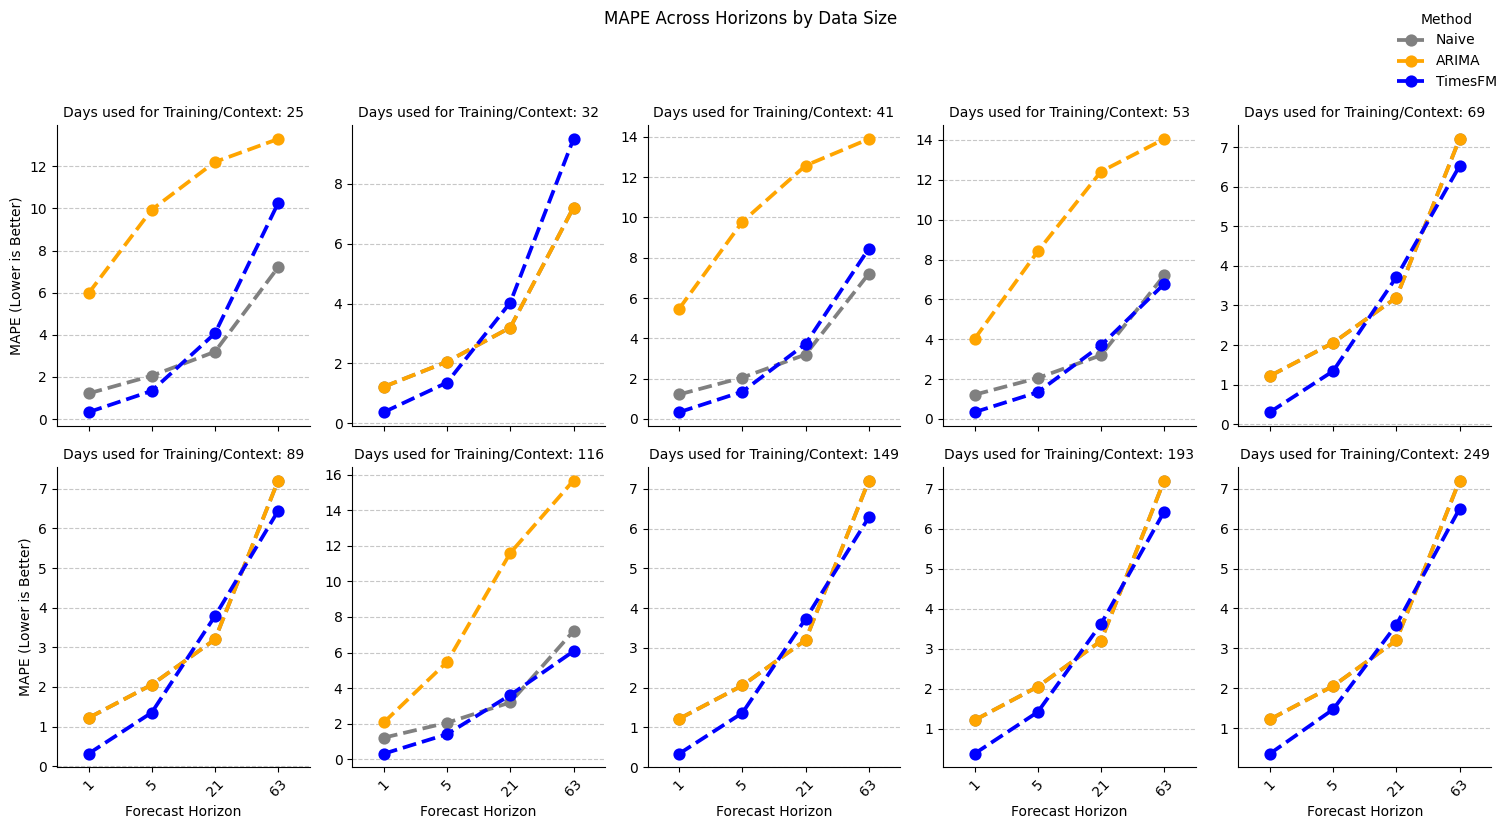

In [89]:
g3 = sns.catplot(
    data=df_mape_results,
    x=horizon_col,
    y=mape_col,
    hue=model_type_col,
    col=days_col,
    kind='point', 
    palette=palette,
    errorbar=None, 
    height=4,
    aspect=0.7,
    order=horizon_length,
    col_order=training_period_value, #
    col_wrap=5,
    linestyle= '--',
    sharey=False
)
g3.figure.suptitle(f'MAPE Across Horizons by Data Size', y=1.03)
g3.set_axis_labels('Forecast Horizon', f'{mape_col} (Lower is Better)')
g3.set_titles("Days used for Training/Context: {col_name}")

sns.move_legend(g3, 'upper right')
for ax in g3.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
    ax.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


In [107]:
from itertools import combinations

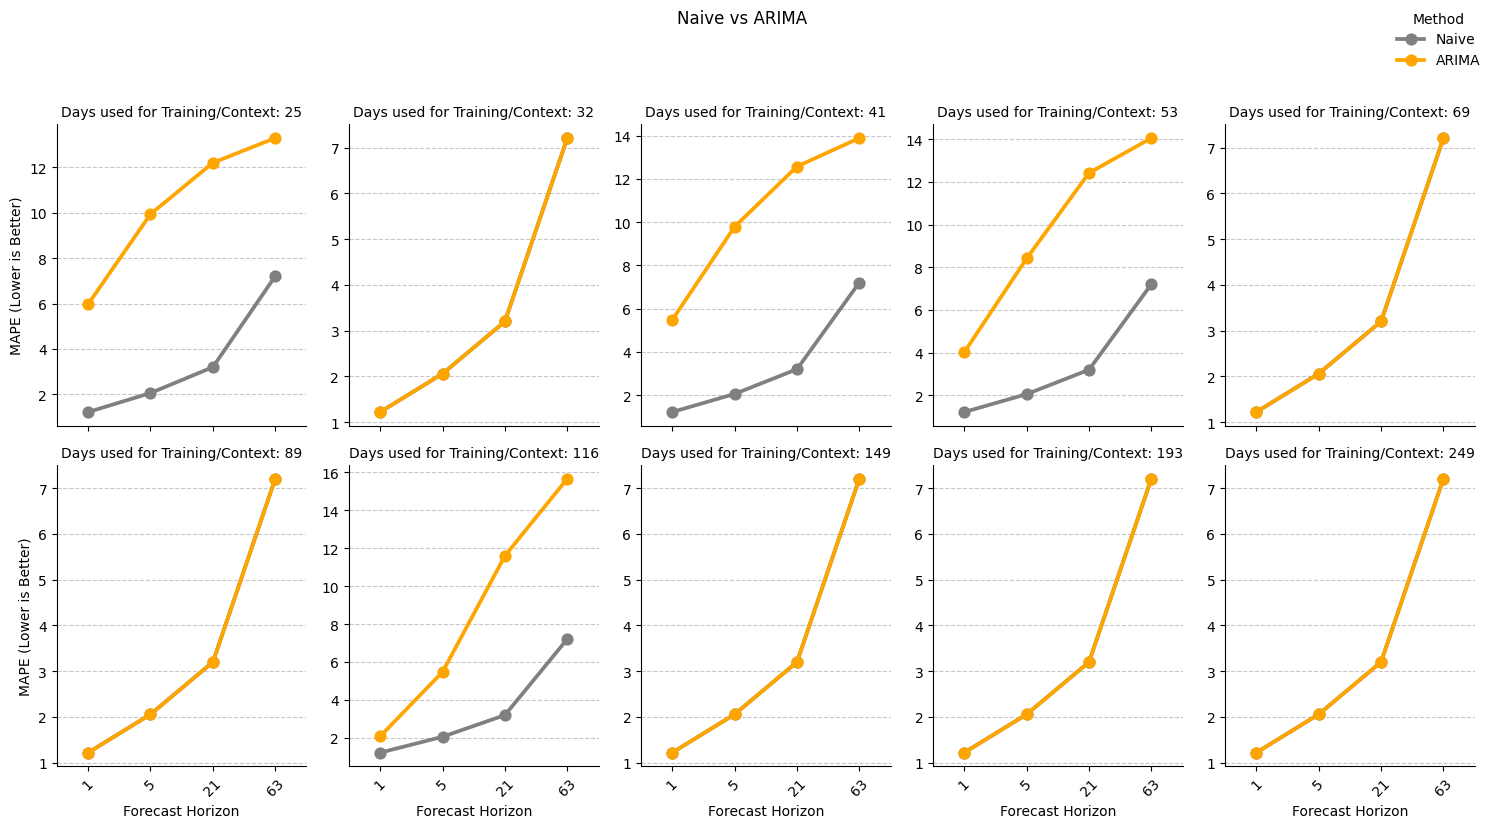

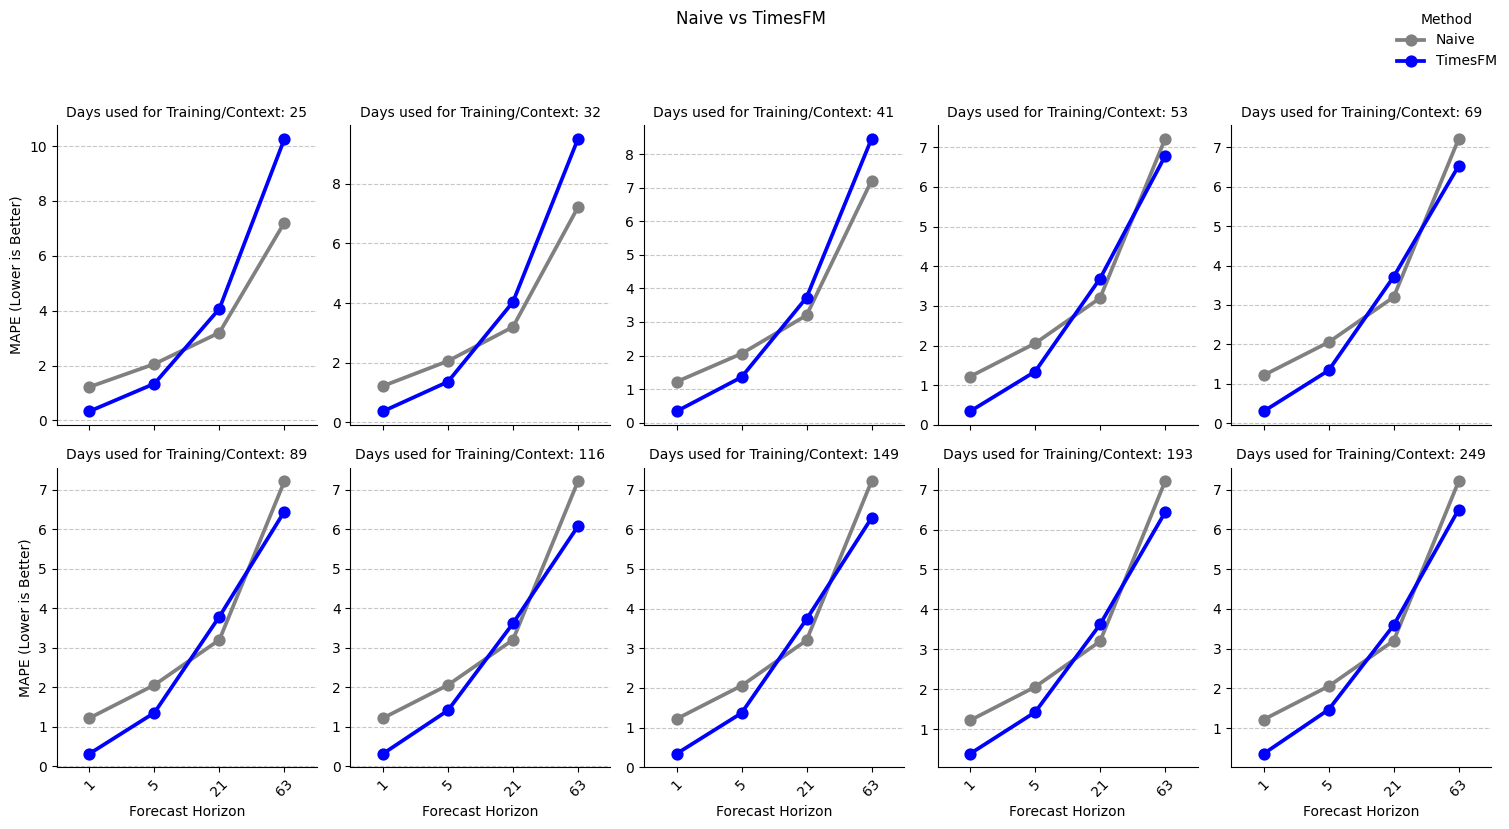

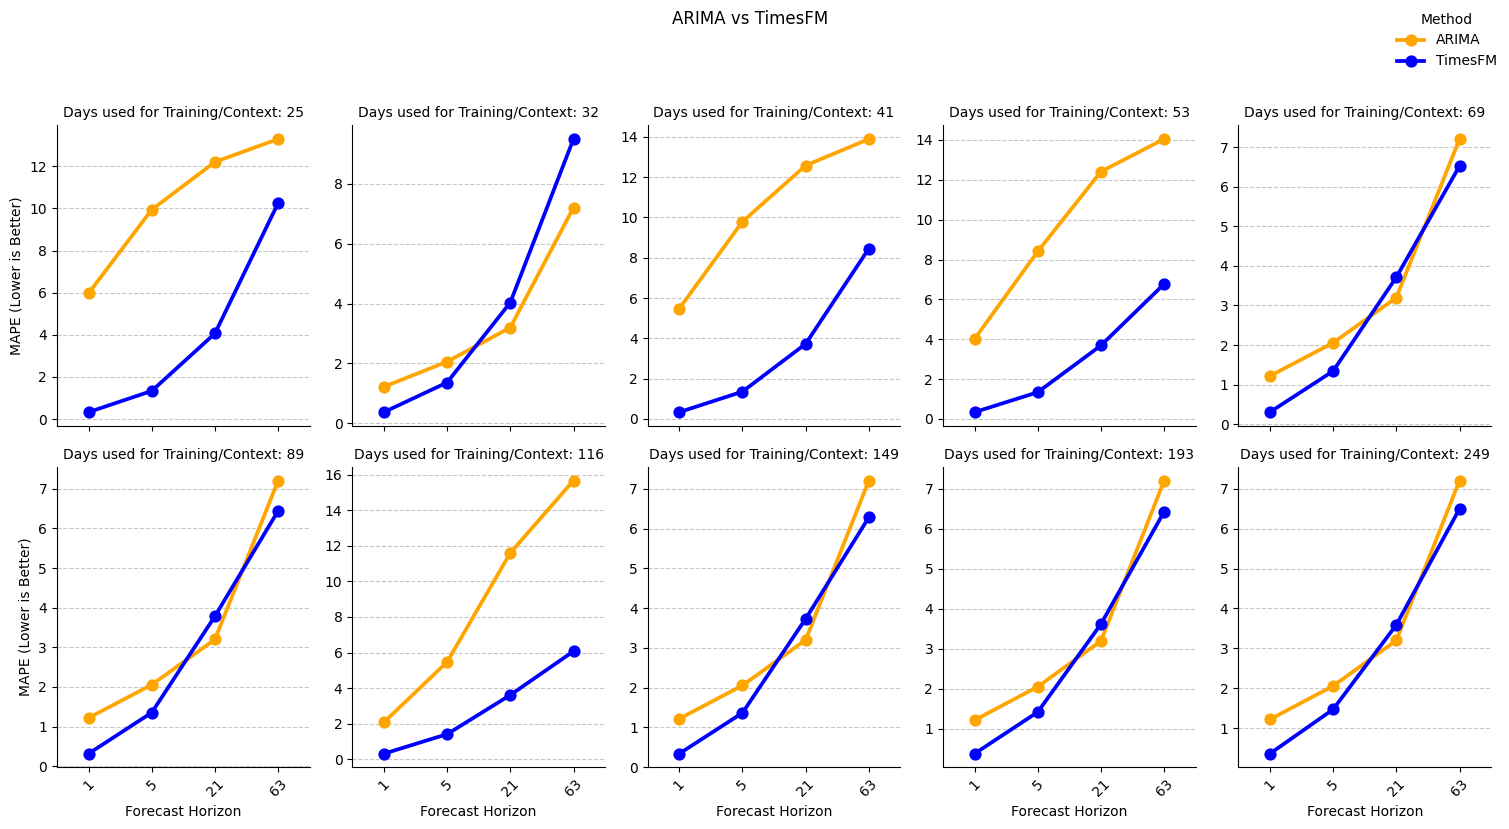

In [108]:
methods = ['Naive', 'ARIMA', 'TimesFM']

for pair1, pair2 in combinations(methods,2):
    # print(pair1, pair2)
    g3 = sns.catplot(
        data=df_mape_results[(df_mape_results['Method'] == pair1) | (df_mape_results['Method'] == pair2)],
        x=horizon_col,
        y=mape_col,
        hue=model_type_col,
        col=days_col,
        kind='point', 
        palette=palette,
        errorbar=None, 
        height=4,
        aspect=0.7,
        order=horizon_length,
        col_order=training_period_value, #
        col_wrap=5, 
        sharey=False
    )
    g3.figure.suptitle(f'{pair1} vs {pair2}', y=1.03)
    g3.set_axis_labels('Forecast Horizon', f'{mape_col} (Lower is Better)')
    g3.set_titles("Days used for Training/Context: {col_name}")

    sns.move_legend(g3, 'upper right')
    for ax in g3.axes.flat:
        for label in ax.get_xticklabels():
            label.set_rotation(45)
        ax.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
